In [1]:
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import statsmodels.api as sm
from pathlib import Path
from scipy import stats

data_dir = Path("/home/qmoreau/gogo_bursts/stat_output")

WIN_START, WIN_END = 0.0, 0.5        # must match TIME_WINDOW in the R script
N_QUANTILES = 3
AGE_LABELS  = ["low", "mid", "high"]
CMAP        = "PuOr"
LINE_COLOR  = "#7a3b8f"              # beta power, distinct from the burst figures

trials = pd.read_csv(data_dir / "beta_power_LONGtoSHORT_trials.csv")
trials["response_time"] = trials["response_time_ms"] / 1000.0

trends = (pd.read_csv(data_dir / "beta_power_LONGtoSHORT_trends.csv")
            .rename(columns={"p.value": "p_value"})
            .sort_values("time"))
trends = trends[trends["SE"].apply(lambda x: pd.notna(x) and np.isfinite(x) and x != 0)]

perm = pd.read_csv(data_dir / "beta_power_LONGtoSHORT_perm_timecourse.csv")
try:
    clusters = pd.read_csv(data_dir / "beta_power_LONGtoSHORT_perm_clusters.csv")
except FileNotFoundError:
    clusters = pd.DataFrame(columns=["start", "end", "p_corr", "outcome", "effect"])

print(f"{len(trials)} pairs, {trials['subject_id'].nunique()} subjects")
print(f"trends: {len(trends)} timepoints | perm: {perm['time'].nunique()} timepoints")
if len(clusters):
    display(clusters[clusters["p_corr"] < 0.05])
else:
    print("no clusters formed at the cluster-forming threshold")


def spans_from_mask(times, mask):
    times, mask = np.asarray(times), np.asarray(mask, dtype=bool)
    if not mask.any():
        return []
    idx = np.flatnonzero(mask)
    brk = np.flatnonzero(np.diff(idx) > 1)
    return list(zip(times[np.r_[idx[0], idx[brk + 1]]],
                    times[np.r_[idx[brk], idx[-1]]]))

1124 pairs, 33 subjects
trends: 501 timepoints | perm: 1501 timepoints


,cluster,start,end,n_times,mass,sign,peak_t,peak_time,p_corr,outcome,effect


Saved → /home/qmoreau/gogo_bursts/stat_output/beta_power_LONGtoSHORT_trend_over_time.pdf


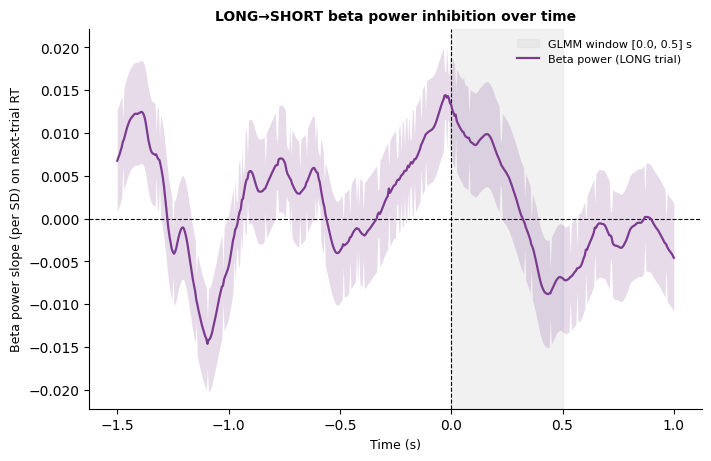

In [2]:
SHOW_UNCORRECTED = False

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5), constrained_layout=True)

ax.axvspan(WIN_START, WIN_END, color="0.85", alpha=0.35, zorder=0,
           label=f"GLMM window [{WIN_START}, {WIN_END}] s")

if "p_corr" in trends.columns and trends["p_corr"].notna().any():
    for i, (s, e) in enumerate(spans_from_mask(trends["time"], trends["p_corr"] < 0.05)):
        ax.axvspan(s, e, color="crimson", alpha=0.16, zorder=0,
                   label="cluster-corrected p < 0.05" if i == 0 else None)
else:
    print("no p_corr column — permutation results not merged into trends CSV")

ax.axhline(0, color="k", ls="--", lw=0.8, zorder=1)
ax.axvline(0, color="k", ls="--", lw=0.8, zorder=1)

ax.fill_between(trends["time"], trends["estimate"] - trends["SE"],
                trends["estimate"] + trends["SE"],
                color=LINE_COLOR, alpha=0.18, lw=0, zorder=2)
ax.plot(trends["time"], trends["estimate"], color=LINE_COLOR, lw=1.6, zorder=3,
        label="Beta power (LONG trial)")

if SHOW_UNCORRECTED:
    sig = trends[trends["p_value"] < 0.05]
    ax.scatter(sig["time"], sig["estimate"], color=LINE_COLOR, s=18, zorder=5)
    ax.text(0.01, 0.02, "dots: uncorrected p < 0.05", transform=ax.transAxes,
            fontsize=7, style="italic", color="0.4")

ax.set_title("LONG→SHORT beta power inhibition over time", fontweight="bold", fontsize=10)
ax.set_xlabel("Time (s)", fontsize=9)
ax.set_ylabel("Beta power slope (per SD) on next-trial RT", fontsize=9)
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

out = data_dir / "beta_power_LONGtoSHORT_trend_over_time.pdf"
fig.savefig(out, bbox_inches="tight", dpi=150); print(f"Saved → {out}")
plt.show()

Saved → /home/qmoreau/gogo_bursts/stat_output/beta_power_LONGtoSHORT_permutation_timecourse.pdf


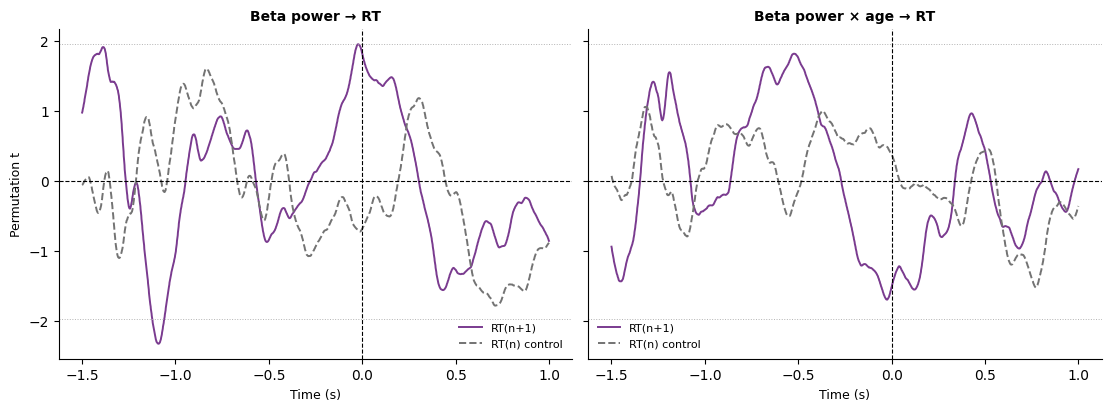

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True, sharey=True)
oc_style = {"next": ("#7a3b8f", "-", "RT(n+1)"), "same": ("0.45", "--", "RT(n) control")}

for ax, eff in zip(axes, ["main", "interaction"]):
    for oc, (color, ls, lbl) in oc_style.items():
        d = perm[(perm["outcome"] == oc) & (perm["effect"] == eff)].sort_values("time")
        if d.empty:
            continue
        ax.plot(d["time"], d["t"], color=color, ls=ls, lw=1.4, label=lbl)
        if oc == "next":
            for i, (s, e) in enumerate(spans_from_mask(d["time"], d["p_corr"] < 0.05)):
                ax.axvspan(s, e, color="crimson", alpha=0.16, zorder=0,
                           label="corrected p < 0.05" if i == 0 else None)

    thr = stats.t.ppf(0.975, 1000)   # ≈1.96, cluster-forming threshold
    ax.axhline(thr,  color="0.7", lw=0.7, ls=":")
    ax.axhline(-thr, color="0.7", lw=0.7, ls=":")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_title({"main": "Beta power → RT",
                  "interaction": "Beta power × age → RT"}[eff],
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Permutation t", fontsize=9)
out = data_dir / "beta_power_LONGtoSHORT_permutation_timecourse.pdf"
fig.savefig(out, bbox_inches="tight", dpi=150); print(f"Saved → {out}")
plt.show()